# การสร้าง Decision Tree เพื่อทำนายอาการหัวใจล้มเหลว

<center>
  <img src="https://www.jcchouinard.com/wp-content/uploads/2021/11/image-1-1024x929.png" width="500"><br>
  ภาพจาก: <a href="https://www.jcchouinard.com/decision-trees-in-machine-learning/">Decision Trees in Machine Learning, with Examples (Python)</a>
</center>

## เตรียมข้อมูล

* เชื่อมต่อ Google Drive
* upload ไฟล์ data/heart.csv
* DecisionTreeClassifier ของ scikit-learn จะสร้าง Binary Tree Classifier
* ข้อมูลที่ใช้จะต้องเปลี่ยนจาก Category เป็น Numeric

| Name | Description | Valuea |
|------|-------------|--------|
| Age | age of the patient | [years] |
| Sex | sex of the patient | [M: Male, F: Female] |
| ChestPainType | chest pain type | [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic] |
| RestingBP | resting blood pressure | [mm Hg] |
| Cholesterol | serum cholesterol | [mm/dl] |
| FastingBS | fasting blood sugar | [1: if FastingBS > 120 mg/dl, 0: otherwise] |
| RestingECG | resting electrocardiogram results | [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria] |
| MaxHR | maximum heart rate achieved | [Numeric value between 60 and 202] |
| ExerciseAngina | exercise-induced angina | [Y: Yes, N: No] |
| Oldpeak | oldpeak = ST | [Numeric value measured in depression] |
| ST_Slope | the slope of the peak exercise ST segment | [Up: upsloping, Flat: flat, Down: downsloping] |
| HeartDisease | output class | [1: heart disease, 0: Normal] |

* สร้าง DataFrame จากไฟล์ data/heart.csv

In [111]:
import pandas as pd

In [112]:
# แก้ไข path ใน pd.read_csv('')
heart_df = pd.read_csv('data/heart.csv')
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


* สำรวจข้อมูล

In [113]:
heart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [114]:
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [115]:
heart_df.describe(include='O')

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_13433/4205671214.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  heart_df.describe(include='O')


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


## Preprocessing

* สร้าง DataFrame ของชุดข้อมูลที่สามารถนำไปใช้ได้

In [116]:
# สร้าง list ของชื่อคอลัมน์ที่เป็น categorical
cat_features = ['ChestPainType',	'RestingECG',	'ST_Slope']

# ลบ column ที่เดี๋ยวจะแปลงค่าภายหลังออกก่อน
heart_enc = heart_df.drop(cat_features, axis=1) #ไม่ได้แก้ไข heart_df ต้นฉบับ
heart_enc

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
0,40,M,140,289,0,172,N,0.0,0
1,49,F,160,180,0,156,N,1.0,1
2,37,M,130,283,0,98,N,0.0,0
3,48,F,138,214,0,108,Y,1.5,1
4,54,M,150,195,0,122,N,0.0,0
...,...,...,...,...,...,...,...,...,...
913,45,M,110,264,0,132,N,1.2,1
914,68,M,144,193,1,141,N,3.4,1
915,57,M,130,131,0,115,Y,1.2,1
916,57,F,130,236,0,174,N,0.0,1


In [117]:
heart_enc.drop(['HeartDisease'], axis=1, inplace=True) # มีผลกับข้อมุล heart_enc ต้นฉบับเลย
heart_enc.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
0,40,M,140,289,0,172,N,0.0
1,49,F,160,180,0,156,N,1.0
2,37,M,130,283,0,98,N,0.0
3,48,F,138,214,0,108,Y,1.5
4,54,M,150,195,0,122,N,0.0


* แปลง Category เป็น Numeric โดยใช้ Series.map()

In [118]:
# เนื่องจาก Sex และ ExerciseAngina มีแค่ 2 ค่า ไม่จำเป็นต้องใช้ OneHotEncoder สามารถใช้คำสั่ง map ได้
heart_enc['Sex'] = heart_enc['Sex'].map({'M':0, 'F':1})
heart_enc.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
0,40,0,140,289,0,172,N,0.0
1,49,1,160,180,0,156,N,1.0
2,37,0,130,283,0,98,N,0.0
3,48,1,138,214,0,108,Y,1.5
4,54,0,150,195,0,122,N,0.0


In [119]:
heart_enc['ExerciseAngina'] = heart_enc['ExerciseAngina'].map({'N':0, 'Y':1})
heart_enc.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
0,40,0,140,289,0,172,0,0.0
1,49,1,160,180,0,156,0,1.0
2,37,0,130,283,0,98,0,0.0
3,48,1,138,214,0,108,1,1.5
4,54,0,150,195,0,122,0,0.0


* แปลง Category เป็น Numeric โดยใช้ OneHotEncoder จาก sklearn.preprocessing

`from sklearn.preprocessing import OneHotEncoder`

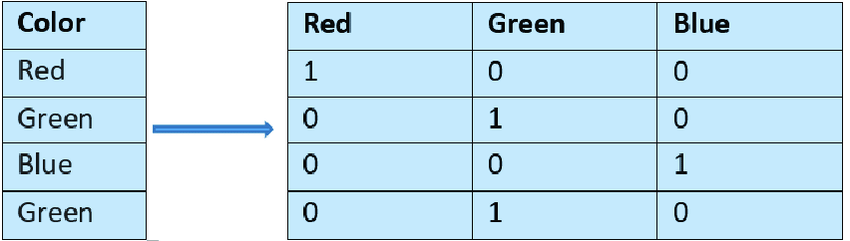

In [120]:
from sklearn.preprocessing import OneHotEncoder

In [121]:
encoder = OneHotEncoder()
tmp = encoder.fit_transform(heart_df[cat_features]) # แปลงแต่ละค่าของ column ให้กลายเป็น one-hot vector ผลลัพธ์จะได้เป็น sparse matrix
tmp.toarray() # แปลง sparse matrix → dense array

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 1.]], shape=(918, 10))

In [122]:
# รายการค่าที่เป็นไปได้ในแต่ละ feature ที่ OneHotEncoder เรียนรู้หลังจาก fit()
# ใช้ดูว่าแต่ละ feature มี category อะไรบ้าง
encoder.categories_

[array(['ASY', 'ATA', 'NAP', 'TA'], dtype=object),
 array(['LVH', 'Normal', 'ST'], dtype=object),
 array(['Down', 'Flat', 'Up'], dtype=object)]

In [123]:
# นำข้อมูลที่ transform แล้ว ไปใส่เพิ่มใน df
# สร้าง list ที่รวมชื่อ feature และชื่อ category ไว้ด้วยกัน
features = [col+'-'+cat
            for col, cats in zip(cat_features, encoder.categories_)
            for cat in cats]
features

['ChestPainType-ASY',
 'ChestPainType-ATA',
 'ChestPainType-NAP',
 'ChestPainType-TA',
 'RestingECG-LVH',
 'RestingECG-Normal',
 'RestingECG-ST',
 'ST_Slope-Down',
 'ST_Slope-Flat',
 'ST_Slope-Up']

In [124]:
# เพิ่ม column ใน heart_enc
heart_enc[features] =tmp.toarray()
heart_enc

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType-ASY,ChestPainType-ATA,ChestPainType-NAP,ChestPainType-TA,RestingECG-LVH,RestingECG-Normal,RestingECG-ST,ST_Slope-Down,ST_Slope-Flat,ST_Slope-Up
0,40,0,140,289,0,172,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,1,160,180,0,156,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,0,130,283,0,98,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,1,138,214,0,108,1,1.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,0,150,195,0,122,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68,0,144,193,1,141,0,3.4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57,0,130,131,0,115,1,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57,1,130,236,0,174,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [125]:
# เปลี่ยน column class ให้ label เป็น text
heart_lbl = heart_df['HeartDisease'].map({1:'heart disease', 0:'normal'})
heart_lbl

0             normal
1      heart disease
2             normal
3      heart disease
4             normal
           ...      
913    heart disease
914    heart disease
915    heart disease
916    heart disease
917           normal
Name: HeartDisease, Length: 918, dtype: str

## แบ่งชุดข้อมูล Train และ Test

`from sklearn.model_selection import train_test_split`

In [126]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(heart_enc, heart_lbl, test_size=0.2, random_state=571)

In [127]:
print(len(X_train), len(X_test))

734 184


## สร้าง Decision Tree
* import library เพื่อสร้าง tree

>`from sklearn.tree import DecisionTreeClassifier`

* สร้าง Tree เปล่า

>`DecisionTreeClassifier()`

* เรียนรู้ข้อมูล

>`fit(X, y)`







In [128]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [129]:
# สร้าง tree เปล่า
classifier = DecisionTreeClassifier(random_state=571)

In [130]:
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",571
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

* ดูความลึกของ tree
```
get_depth()
```

In [131]:
classifier.get_depth()

12

* วาด tree

In [132]:
import matplotlib.pyplot as plt

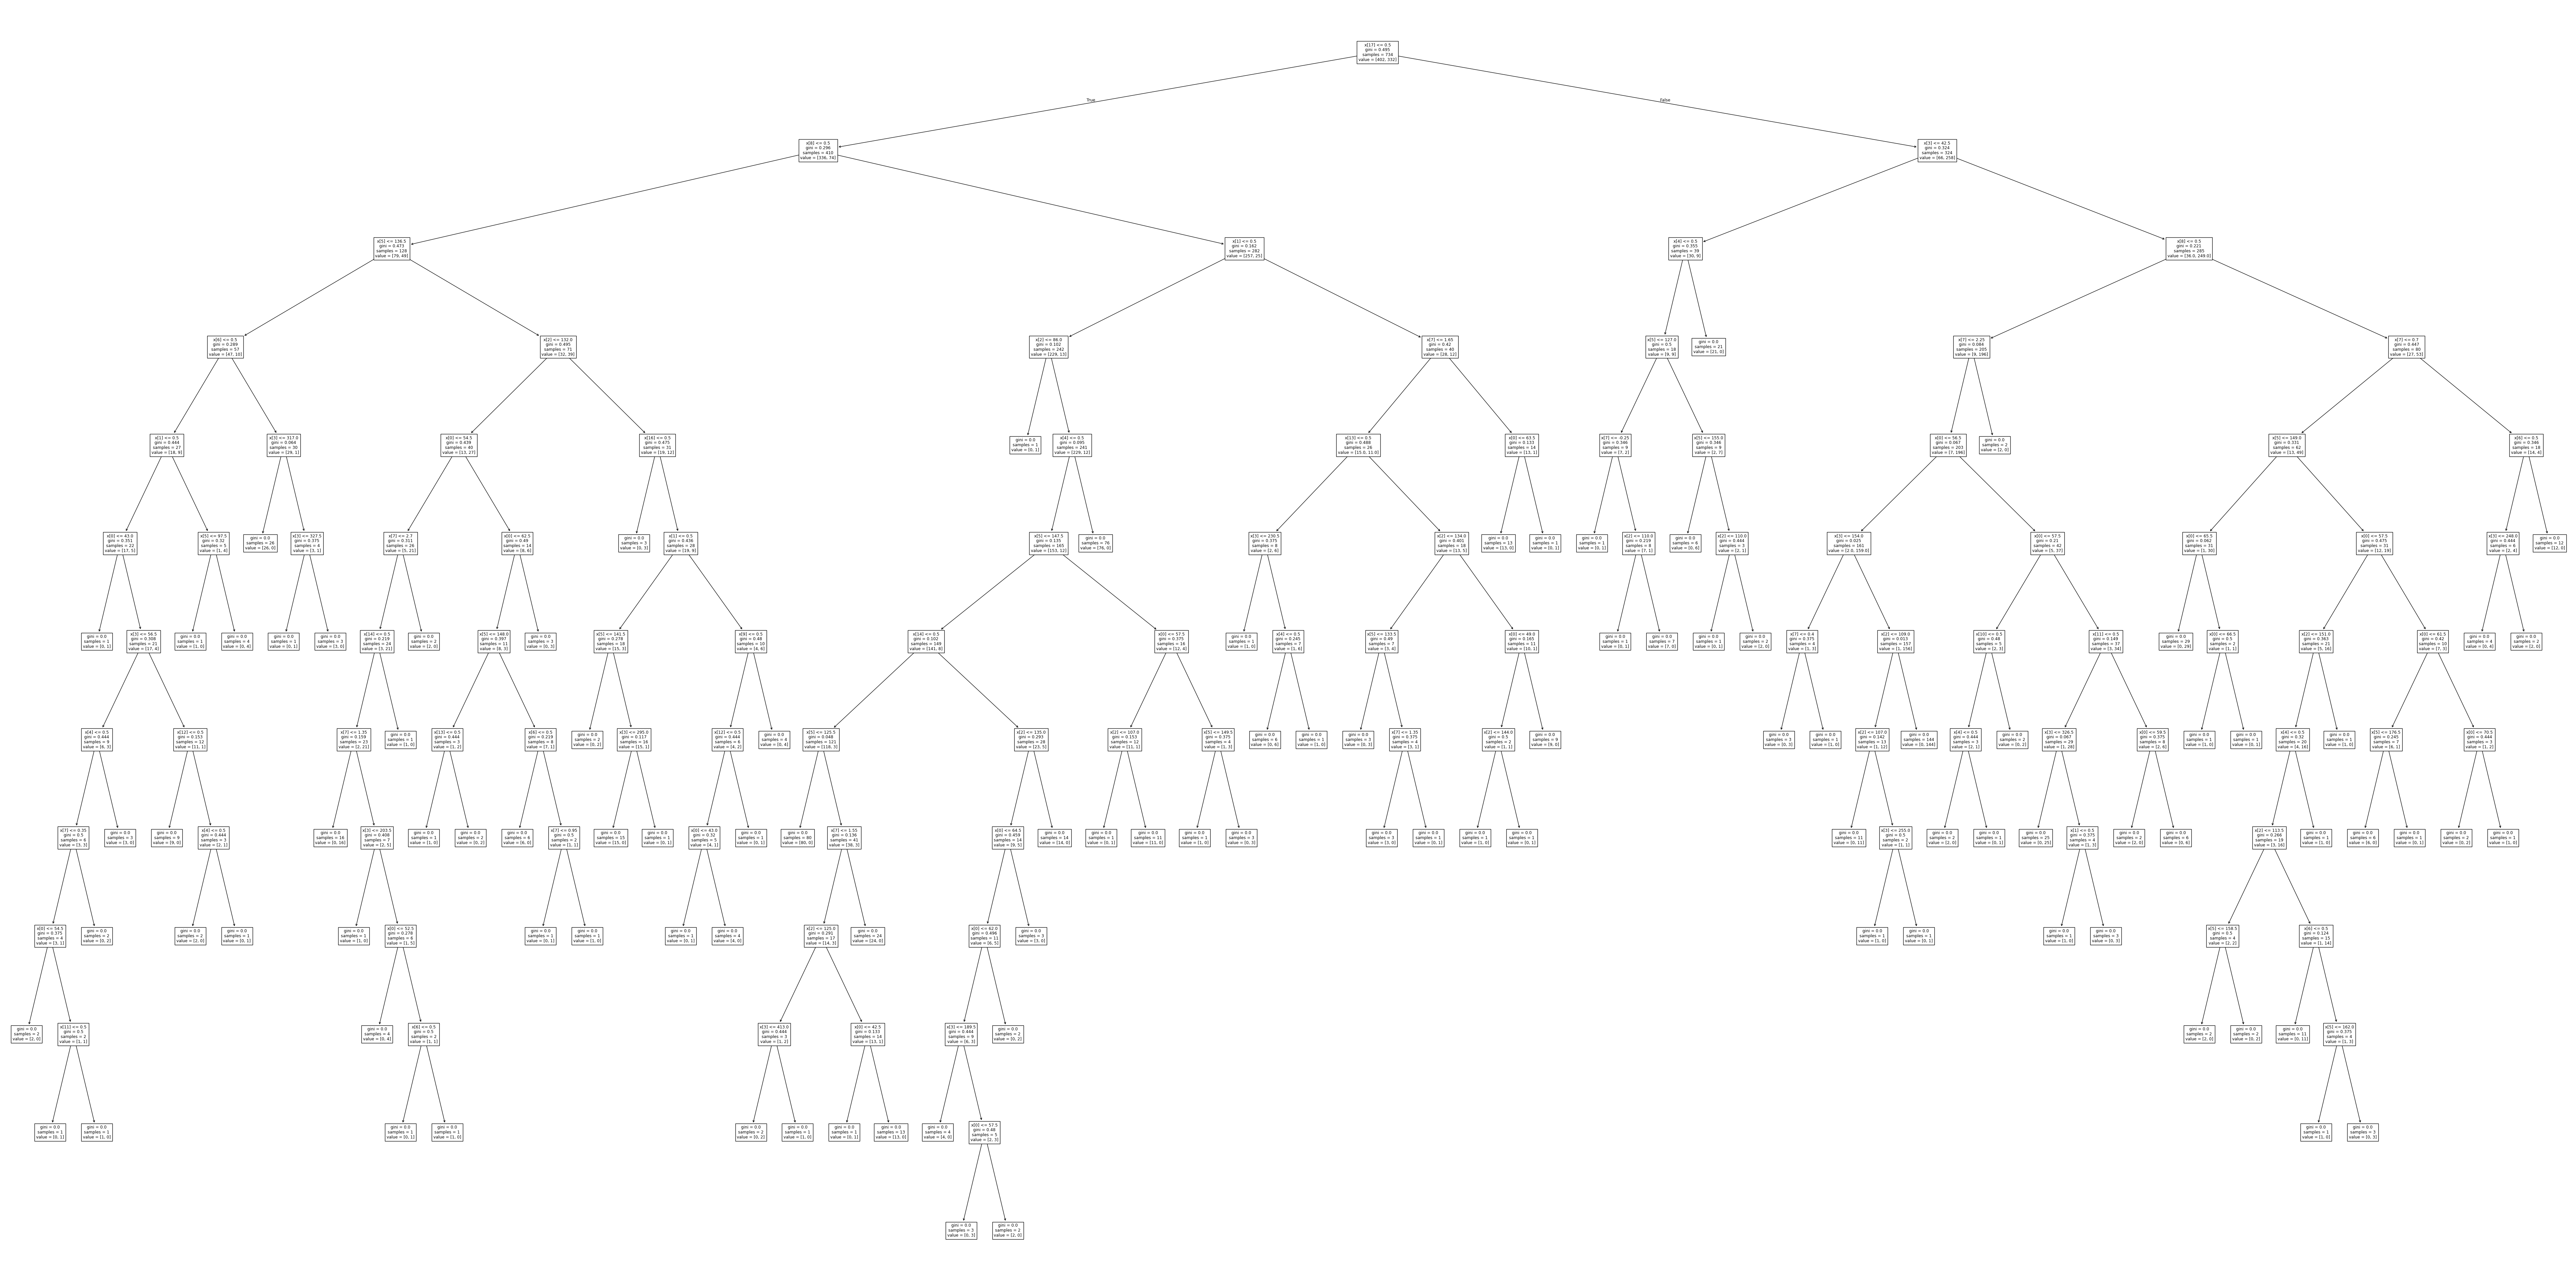

In [133]:
plt.figure(figsize=(100, 50))
plot_tree(classifier)
plt.show()

## วัดประสิทธิภาพ

* ทำนายค่าจากชุดข้อมูล test

In [134]:
y_predict = classifier.predict(X_test)
y_predict

array(['normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'heart disease', 'normal', 'normal', 'heart disease',
       'heart disease', 'normal', 'normal', 'normal', 'normal',
       'heart disease', 'heart disease', 'normal', 'normal', 'normal',
       'heart disease', 'heart disease', 'heart disease', 'normal',
       'normal', 'normal', 'normal', 'heart disease', 'normal', 'normal',
       'heart disease', 'heart disease', 'normal', 'normal', 'normal',
       'heart disease', 'normal', 'normal', 'heart disease',
       'heart disease', 'heart disease', 'normal', 'heart disease',
       'heart disease', 'normal', 'heart disease', 'heart disease',
       'normal', 'normal', 'normal', 'normal', 'normal', 'heart disease',
       'heart disease', 'heart disease', 'heart disease', 'heart disease',
       'heart disease', 'normal', 'heart disease', 'heart disease',
       'normal', 'heart disease', 'normal', 'normal', 'normal',
       'heart disease', 'heart disease', 'norm

* คำนวณ Confusion matrix

`from sklearn.metrics import classification_report`

In [135]:
from sklearn.metrics import classification_report

In [136]:
print(classification_report(y_test, y_predict))

               precision    recall  f1-score   support

heart disease       0.82      0.79      0.81       106
       normal       0.73      0.77      0.75        78

     accuracy                           0.78       184
    macro avg       0.78      0.78      0.78       184
 weighted avg       0.78      0.78      0.78       184



## ปรับความลึกของ Tree

* พิจารณาจากค่า accuracy
```
from sklearn.metrics import accuracy_score
```

In [137]:
from sklearn.metrics import accuracy_score

In [138]:
for d in range(2,12):
  cl = DecisionTreeClassifier(random_state=571, max_depth=d)
  cl.fit(X_train, y_train)
  y_tmp = cl.predict(X_test)
  print(d, accuracy_score(y_test, y_tmp))

2 0.8260869565217391
3 0.8206521739130435
4 0.8206521739130435
5 0.8369565217391305
6 0.8315217391304348
7 0.8152173913043478
8 0.8152173913043478
9 0.8315217391304348
10 0.7989130434782609
11 0.7717391304347826


In [139]:
classifier5 = DecisionTreeClassifier(random_state=571, max_depth=5)
classifier5.fit(X_train, y_train)
y_predict5 = classifier5.predict(X_test)
print(classification_report(y_test, y_predict5))

               precision    recall  f1-score   support

heart disease       0.86      0.86      0.86       106
       normal       0.81      0.81      0.81        78

     accuracy                           0.84       184
    macro avg       0.83      0.83      0.83       184
 weighted avg       0.84      0.84      0.84       184



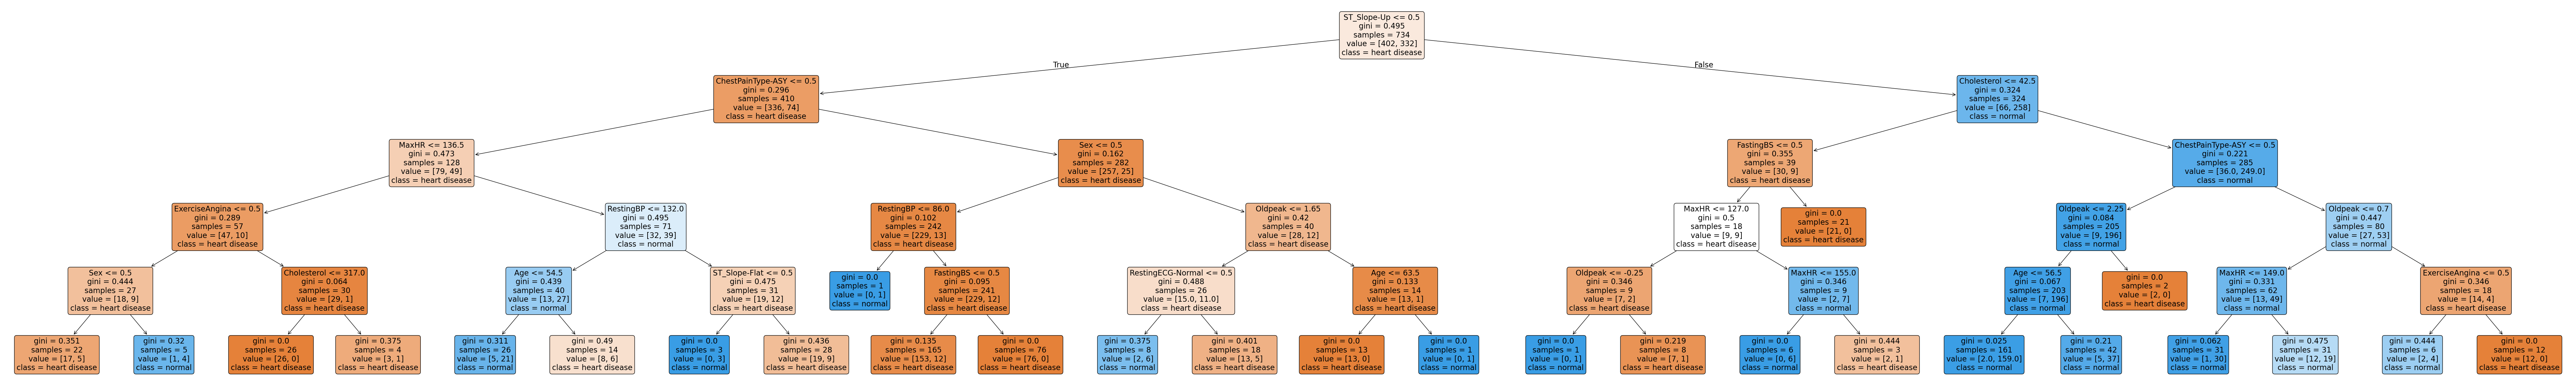

In [140]:
plt.figure(figsize=(100, 15))
plot_tree(classifier5, feature_names=heart_enc.columns,
          class_names=classifier5.classes_, filled=True, rounded=True)
plt.show()

# Challenge: Predict New Patients

In [141]:
new_patients = pd.read_csv('data/new_patients.csv')
new_patients

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,Y,0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1,Flat
2,37,M,ATA,130,283,0,ST,98,N,0,Up
3,38,M,ASY,110,196,0,ST,166,N,0,Flat
4,51,M,ATA,125,188,0,Normal,145,Y,0,Up
5,53,M,NAP,145,518,0,Normal,130,N,0,Flat
6,63,M,ASY,150,223,0,Normal,115,Y,0,Flat


## Preprocess new patients (same steps as training data)

In [142]:
cat_features = ['ChestPainType', 'RestingECG', 'ST_Slope']

# Drop categorical columns (will be added back after encoding)
patient_enc = new_patients.drop(cat_features, axis=1)

# Map binary columns exactly as in training
patient_enc['Sex'] = patient_enc['Sex'].map({'M': 0, 'F': 1})
patient_enc['ExerciseAngina'] = patient_enc['ExerciseAngina'].map({'N': 0, 'Y': 1})

# Use the SAME encoder fitted on heart_df (transform only — do NOT refit)
tmp_new = encoder.transform(new_patients[cat_features])
patient_enc[features] = tmp_new.toarray()

patient_enc

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType-ASY,ChestPainType-ATA,ChestPainType-NAP,ChestPainType-TA,RestingECG-LVH,RestingECG-Normal,RestingECG-ST,ST_Slope-Down,ST_Slope-Flat,ST_Slope-Up
0,40,0,140,289,0,172,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,1,160,180,0,156,0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,0,130,283,0,98,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,38,0,110,196,0,166,0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,51,0,125,188,0,145,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,53,0,145,518,0,130,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,63,0,150,223,0,115,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Predict

In [143]:
y_new = classifier5.predict(patient_enc)

result_df = new_patients.copy()
result_df['Prediction'] = y_new
result_df['Prediction_Label'] = result_df['Prediction'].map({1: 'Heart Disease', 0: 'Normal'})
result_df[['Age', 'Sex', 'ChestPainType', 'Prediction_Label']]

,Age,Sex,ChestPainType,Prediction_Label
0,40,M,ATA,NaN
1,49,F,NAP,NaN
2,37,M,ATA,NaN
3,38,M,ASY,NaN
4,51,M,ATA,NaN
5,53,M,NAP,NaN
6,63,M,ASY,NaN
